# Notebook 4 — Evaluation, Error Analysis & Comparative Performance
## KIIT-MiTA: High-Resolution Drone Imagery for Military Object Detection

**CSE 445 — Computer Vision**

| | |
|---|---|
| **Group Number** | `02` |
| **Instructor** | Dr. Mohammad Rifat Ahmmad Rashid, Associate Professor, Dept. of CSE, EWU |

| Name | ID |
|---|---|
| MD SHAFIN AHAMED SIAM | 2023-1-60-007 |
| ALBIN ISRAT SIDDIQUE | 2023-1-60-212 |
| Md. Ariful Islam Opi | 2023-1-60-141 |
| Nasrullah Kaisher Sijan | 2023-1-60-204 |

| Property | Value |
|---|---|
| **Dataset** | KIIT-MiTA (Military Target Detection), re-split output from Notebook 1 |
| **Source** | https://data.mendeley.com/datasets/drjmrf5kk5/1 |
| **Models evaluated here** | YOLOv10-s, YOLOv12-s, YOLOv26-s (Notebook 2), RF-DETR Nano (Notebook 3) |
| **Hardware** | Kaggle T4 x1 (single GPU, `device=0`) |

---
## 1. Environment Setup
Installs `ultralytics` (YOLOv10/v12/v26), `rfdetr` + `supervision` (RF-DETR Nano), and `thop` (used for
the FLOPs comparison in Section 6.2, with a fallback if a given architecture doesn't profile cleanly).

In [1]:
!pip install -q ultralytics
!pip install -q "rfdetr[train,loggers]" supervision pycocotools
!pip install -q thop scikit-learn

import os, json, time, pathlib, yaml, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from pathlib import Path
from PIL import Image
from IPython.display import display

import torch
from ultralytics import YOLO
from rfdetr import RFDETRNano
import supervision as sv
from sklearn.metrics import roc_curve, auc

print("torch       :", torch.__version__)
print("cuda avail  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device      :", torch.cuda.get_device_name(0))
print("supervision :", sv.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.

/usr/local/lib/python3.12/dist-packages/rfdetr/models/weights.py:258: FutureWarning: target=True is deprecated since `v0.8`; use `TargetMode.ARGS_REMAP` instead. Will be removed in `v1.0`.
  @deprecated(target=True, args_mapping={"train_config": None}, deprecated_in="1.7.0", remove_in="1.9.0", num_warns=-1)


---
## 2. CONFIG Cell
Same discipline as Notebooks 1-3: every path, threshold, and constant lives here. This notebook needs
**three** Kaggle dataset inputs attached — Notebook 1's re-split output (for the test images/labels),
Notebook 2's output (3 YOLO checkpoints + `model_results.json`), and Notebook 3's output (RF-DETR
checkpoint + its `model_results.json`).

In [2]:
# ==================== CONFIG CELL ====================

def discover_data_yaml(search_base="/kaggle/input"):
    """Find Notebook 1's data.yaml specifically. There can be multiple data.yaml files under
    /kaggle/input (Notebook 2 and 3 each bundle their own working copy into their committed output
    too), so a candidate is only accepted if its parent folder actually has train/val/test image
    directories sitting next to it on disk."""
    search = pathlib.Path(search_base)
    if not search.exists():
        search = pathlib.Path(".")
    candidates = list(search.rglob("data.yaml"))
    valid = []
    for p in candidates:
        try:
            with open(p) as f:
                cfg = yaml.safe_load(f)
        except Exception:
            continue
        if not (isinstance(cfg, dict) and "names" in cfg and "nc" in cfg):
            continue
        root = p.parent
        if (root / "train" / "images").exists() and (root / "val" / "images").exists() \
                and (root / "test" / "images").exists():
            valid.append(p)

    if not valid:
        print("data.yaml candidates seen (none had a full train/val/test layout next to them):")
        for p in candidates:
            print(f"  {p}")
        raise FileNotFoundError(
            f"Could not find Notebook 1's resplit data.yaml under {search_base}. "
            "Make sure the Notebook 1 output is attached as an input."
        )
    return valid[0]


def discover_all(pattern, search_base="/kaggle/input"):
    search = pathlib.Path(search_base)
    if not search.exists():
        search = pathlib.Path(".")
    return sorted(search.rglob(pattern))


DATA_YAML = discover_data_yaml()
RESPLIT_ROOT = DATA_YAML.parent

with open(DATA_YAML) as f:
    _data_cfg = yaml.safe_load(f)
CLASS_NAMES = _data_cfg["names"]
NUM_CLASSES = _data_cfg["nc"]

TEST_IMG_DIR = RESPLIT_ROOT / "test" / "images"
TEST_LBL_DIR = RESPLIT_ROOT / "test" / "labels"
if not TEST_IMG_DIR.exists():
    raise FileNotFoundError(f"Expected test images at {TEST_IMG_DIR} but it does not exist.")

# ---- merge model_results.json from Notebook 2's output and Notebook 3's output ----
results_store = {}
for p in discover_all("model_results.json"):
    with open(p) as f:
        part = json.load(f)
    print(f"loaded {len(part)} model(s) from {p}: {list(part.keys())}")
    results_store.update(part)

EXPECTED_MODELS = {"yolov10s", "yolov12s", "yolov26s", "rfdetr_nano"}
missing = EXPECTED_MODELS - set(results_store.keys())
if missing:
    print(f"\nWARNING - missing self-reported results for: {missing}")
    print("Notebook 4 can still run for whichever models ARE present.")

# ---- locate checkpoints ----
_pt_files = discover_all("*.pt")
CHECKPOINTS = {}
_patterns = {
    "yolov10s": "yolov10s_best.pt",
    "yolov12s": "yolov12s_best.pt",
    "yolov26s": "yolov26s_best.pt",
    "rfdetr_nano": "rfdetr_nano_best_ema.pt",
}
for key, fname in _patterns.items():
    match = next((p for p in _pt_files if p.name == fname), None)
    if match is not None:
        CHECKPOINTS[key] = match

print("\nCheckpoints found:")
for key in _patterns:
    print(f"  {key:12s}: {CHECKPOINTS.get(key, 'NOT FOUND')}")

IMG_SIZE = 640
DEVICE = 0
SEED = 42

IOU_MATCH_THRESHOLD = 0.5     # IoU + correct class => true positive, at the reported operating point
IOU_LOCALIZATION_MIN = 0.10   # correct class, IoU in [0.10, 0.50) => localization error, not a miss
CONF_THRESHOLD = 0.25         # operating-point score cutoff for the confusion matrix / galleries
RAW_CONF_FLOOR = 0.001        # near-zero floor used when *caching* predictions for PR/F1/ROC/AP curves
N_GALLERY_EXAMPLES = 3        # examples per error type per model in Section 8

OUTPUT_DIR = pathlib.Path("/kaggle/working/notebook4_eval")
ROBUST_DIR = pathlib.Path("/kaggle/working/robustness")
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ROBUST_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a completed figure to PLOTS_DIR before/alongside plt.show(). Without this, every plot in
    this notebook would only exist as an inline cell output (embedded in the .ipynb on save, but not
    retrievable as a standalone image file for the report/appendix/slides)."""
    fig.savefig(PLOTS_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    print(f"  saved: {PLOTS_DIR / f'{name}.png'}")

print(f"\ndata.yaml        : {DATA_YAML}")
print(f"test images      : {TEST_IMG_DIR}  ({len(list(TEST_IMG_DIR.glob('*')))} files)")
print(f"test labels      : {TEST_LBL_DIR}  ({len(list(TEST_LBL_DIR.glob('*')))} files)")
print(f"classes ({NUM_CLASSES})      : {CLASS_NAMES}")
print(f"iou match thresh : {IOU_MATCH_THRESHOLD}")
print(f"iou loc min      : {IOU_LOCALIZATION_MIN}")
print(f"conf threshold   : {CONF_THRESHOLD}")
print(f"raw conf floor   : {RAW_CONF_FLOOR}")


loaded 3 model(s) from /kaggle/input/notebooks/arifulislamopi/notebook-2-yolo-model-training-yolov10-v12-v26/model_results.json: ['yolov10s', 'yolov12s', 'yolov26s']
loaded 1 model(s) from /kaggle/input/notebooks/arifulislamopi/notebook-3-rf-detr-nano-training/model_results.json: ['rfdetr_nano']

Checkpoints found:
  yolov10s    : /kaggle/input/notebooks/arifulislamopi/notebook-2-yolo-model-training-yolov10-v12-v26/checkpoints/yolov10s_best.pt
  yolov12s    : /kaggle/input/notebooks/arifulislamopi/notebook-2-yolo-model-training-yolov10-v12-v26/checkpoints/yolov12s_best.pt
  yolov26s    : /kaggle/input/notebooks/arifulislamopi/notebook-2-yolo-model-training-yolov10-v12-v26/checkpoints/yolov26s_best.pt
  rfdetr_nano : /kaggle/input/notebooks/arifulislamopi/notebook-3-rf-detr-nano-training/checkpoints/rfdetr_nano_best_ema.pt

data.yaml        : /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/data.yaml
test images      : /kaggle/input/notebooks/arifulislamopi/

---
## 3. Load Best Checkpoints for All Four Models

Task 4.6 step 1. `yolov10s` / `yolov12s` / `yolov26s` load through `ultralytics.YOLO`; RF-DETR Nano
loads through its own `RFDETRNano(pretrain_weights=...)` constructor, which is why the two families
need separate wrapper logic everywhere below rather than one shared `model.predict(...)` call.

In [3]:
MODEL_TYPE = {
    "yolov10s": "yolo",
    "yolov12s": "yolo",
    "yolov26s": "yolo",
    "rfdetr_nano": "rfdetr",
}
DISPLAY_NAME = {
    "yolov10s": "YOLOv10-s",
    "yolov12s": "YOLOv12-s",
    "yolov26s": "YOLOv26-s",
    "rfdetr_nano": "RF-DETR Nano",
}

MODELS = {}
for key, ckpt_path in CHECKPOINTS.items():
    if MODEL_TYPE[key] == "yolo":
        MODELS[key] = YOLO(str(ckpt_path))
    else:
        MODELS[key] = RFDETRNano(pretrain_weights=str(ckpt_path))
    print(f"loaded {key:12s} <- {ckpt_path}")

print(f"\n{len(MODELS)} / 4 models loaded: {list(MODELS.keys())}")


loaded yolov10s     <- /kaggle/input/notebooks/arifulislamopi/notebook-2-yolo-model-training-yolov10-v12-v26/checkpoints/yolov10s_best.pt
loaded yolov12s     <- /kaggle/input/notebooks/arifulislamopi/notebook-2-yolo-model-training-yolov10-v12-v26/checkpoints/yolov12s_best.pt


[2026-07-11 18:55:42] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-11 18:55:42] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


loaded yolov26s     <- /kaggle/input/notebooks/arifulislamopi/notebook-2-yolo-model-training-yolov10-v12-v26/checkpoints/yolov26s_best.pt


[2026-07-11 18:55:45] [WARNING] rf-detr - Checkpoint has 7 classes but model is configured for 90. Using checkpoint class count (7). Pass num_classes=7 to suppress this warning.
[2026-07-11 18:55:45] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


loaded rfdetr_nano  <- /kaggle/input/notebooks/arifulislamopi/notebook-3-rf-detr-nano-training/checkpoints/rfdetr_nano_best_ema.pt

4 / 4 models loaded: ['yolov10s', 'yolov12s', 'yolov26s', 'rfdetr_nano']


---
## 4. Shared Ground-Truth / Prediction / Metric Helpers

In [4]:
def load_gt_xyxy(img_path, lbl_dir):
    """YOLO-normalised (cx, cy, w, h) labels -> absolute-pixel (x1, y1, x2, y2)."""
    with Image.open(img_path) as im:
        w, h = im.size
    lbl_path = lbl_dir / f"{img_path.stem}.txt"
    boxes, labels = [], []
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cid = int(float(parts[0]))
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                x2 = (cx + bw / 2) * w
                y2 = (cy + bh / 2) * h
                boxes.append([x1, y1, x2, y2])
                labels.append(cid)
    return np.array(boxes, dtype=np.float64), np.array(labels, dtype=np.int64), (w, h)


def get_predictions(model_key, img_path, conf_threshold=RAW_CONF_FLOOR):
    """Returns (boxes_xyxy [N,4], labels [N], scores [N]) as numpy arrays, for any of the four models."""
    model = MODELS[model_key]

    if MODEL_TYPE[model_key] == "yolo":
        result = model.predict(str(img_path), imgsz=IMG_SIZE, device=DEVICE,
                                conf=conf_threshold, verbose=False)[0]
        boxes = result.boxes.xyxy.cpu().numpy()
        labels = result.boxes.cls.cpu().numpy().astype(np.int64)
        scores = result.boxes.conf.cpu().numpy()
    else:
        img = Image.open(img_path).convert("RGB")
        det = model.predict(img, threshold=conf_threshold)
        boxes = np.array(det.xyxy, dtype=np.float64) if len(det) else np.zeros((0, 4))
        labels = np.array(det.class_id, dtype=np.int64) if len(det) else np.zeros((0,), dtype=np.int64)
        scores = np.array(det.confidence, dtype=np.float64) if len(det) else np.zeros((0,))

    return boxes, labels, scores


def iou_xyxy(box_a, boxes_b):
    """IoU of one box against an array of boxes, all in absolute xyxy pixels."""
    if len(boxes_b) == 0:
        return np.zeros((0,))
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = boxes_b[:, 0], boxes_b[:, 1], boxes_b[:, 2], boxes_b[:, 3]
    ix1, iy1 = np.maximum(ax1, bx1), np.maximum(ay1, by1)
    ix2, iy2 = np.minimum(ax2, bx2), np.minimum(ay2, by2)
    iw, ih = np.clip(ix2 - ix1, 0, None), np.clip(iy2 - iy1, 0, None)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = np.clip(bx2 - bx1, 0, None) * np.clip(by2 - by1, 0, None)
    union = area_a + area_b - inter
    return np.where(union > 0, inter / union, 0.0)


def size_bucket(box_xyxy):
    """COCO-style small/medium/large, same thresholds as Notebook 1's EDA."""
    area = max(0.0, box_xyxy[2] - box_xyxy[0]) * max(0.0, box_xyxy[3] - box_xyxy[1])
    if area < 32 ** 2:
        return "small"
    if area < 96 ** 2:
        return "medium"
    return "large"


def compute_mcc_from_confusion_matrix(cm):
    """Same Gorodkin multiclass-MCC generalisation used in Notebooks 2 and 3."""
    cm = np.array(cm, dtype=np.float64)
    t_k, p_k = cm.sum(axis=1), cm.sum(axis=0)
    c, s = np.trace(cm), cm.sum()
    denom = np.sqrt((s ** 2 - np.dot(p_k, p_k)) * (s ** 2 - np.dot(t_k, t_k)))
    return float((c * s - np.dot(t_k, p_k)) / denom) if denom != 0 else 0.0


def per_class_prf_from_cm(cm):
    per_class = {}
    for i, name in enumerate(CLASS_NAMES):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        per_class[name] = {"precision": float(precision), "recall": float(recall), "f1": float(f1)}
    return per_class


def macro_metrics_from_cm(cm):
    per_class = per_class_prf_from_cm(cm)
    macro_p = float(np.mean([v["precision"] for v in per_class.values()]))
    macro_r = float(np.mean([v["recall"] for v in per_class.values()]))
    macro_f1 = float(np.mean([v["f1"] for v in per_class.values()]))
    return {
        "precision": macro_p, "recall": macro_r, "f1": macro_f1,
        "mcc": compute_mcc_from_confusion_matrix(cm),
        "per_class": per_class,
        "confusion_matrix": {"labels": list(CLASS_NAMES) + ["background"], "matrix": np.array(cm).tolist()},
    }


print("Helpers ready.")


Helpers ready.


---
## 5. Single Cached Inference Pass

### 5.1 Collect Raw Predictions (once per model)

In [5]:
def collect_raw_predictions(model_key):
    records = []
    for img_path in sorted(TEST_IMG_DIR.glob("*")):
        gt_boxes, gt_labels, _ = load_gt_xyxy(img_path, TEST_LBL_DIR)
        pred_boxes, pred_labels, pred_scores = get_predictions(model_key, img_path, conf_threshold=RAW_CONF_FLOOR)
        records.append(dict(img_path=img_path, gt_boxes=gt_boxes, gt_labels=gt_labels,
                             pred_boxes=pred_boxes, pred_labels=pred_labels, pred_scores=pred_scores))
    return records


raw_predictions = {}
for key in MODELS:
    print(f"collecting raw predictions for {key} ...")
    raw_predictions[key] = collect_raw_predictions(key)
    n_pred = sum(len(r["pred_scores"]) for r in raw_predictions[key])
    print(f"  {len(raw_predictions[key])} images, {n_pred} raw detections cached")


collecting raw predictions for yolov10s ...
  178 images, 7668 raw detections cached
collecting raw predictions for yolov12s ...
  178 images, 5484 raw detections cached
collecting raw predictions for yolov26s ...


[2026-07-11 18:56:02] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.optimize_for_inference(dtype=torch.float16).


  178 images, 4854 raw detections cached
collecting raw predictions for rfdetr_nano ...
  178 images, 53400 raw detections cached


### 5.2 Build Detection Records — Confusion Matrix, Curve Labels, and the Full Catalog

In [6]:
def build_detection_records(model_key, conf_threshold=CONF_THRESHOLD, iou_thresh=IOU_MATCH_THRESHOLD):
    n = NUM_CLASSES
    cm = np.zeros((n + 1, n + 1), dtype=np.int64)
    det_scores, det_is_tp = [], []
    examples = []

    for rec in raw_predictions[model_key]:
        keep = rec["pred_scores"] >= conf_threshold
        pred_boxes = rec["pred_boxes"][keep]
        pred_labels = rec["pred_labels"][keep]
        pred_scores = rec["pred_scores"][keep]
        gt_boxes, gt_labels = rec["gt_boxes"], rec["gt_labels"]

        order = np.argsort(-pred_scores)
        gt_matched = np.zeros(len(gt_boxes), dtype=bool)

        for i in order:
            pbox, plabel, pscore = pred_boxes[i], pred_labels[i], pred_scores[i]

            if len(gt_boxes) == 0:
                cm[n, plabel] += 1
                det_scores.append(pscore); det_is_tp.append(0)
                examples.append(dict(kind="false_positive", img_path=rec["img_path"], pred_box=pbox,
                                      pred_label=plabel, score=pscore, gt_box=None, gt_label=None,
                                      size=size_bucket(pbox)))
                continue

            ious = iou_xyxy(pbox, gt_boxes)
            same_class = gt_labels == plabel
            ious_avail = np.where(gt_matched, -1, ious)
            best_j = int(np.argmax(ious_avail))
            best_iou = ious_avail[best_j]

            if best_iou >= iou_thresh and same_class[best_j]:
                cm[gt_labels[best_j], plabel] += 1
                gt_matched[best_j] = True
                det_scores.append(pscore); det_is_tp.append(1)
                examples.append(dict(kind="true_positive", img_path=rec["img_path"], pred_box=pbox,
                                      pred_label=plabel, score=pscore, gt_box=gt_boxes[best_j],
                                      gt_label=gt_labels[best_j], size=size_bucket(gt_boxes[best_j])))
            elif best_iou >= iou_thresh and not same_class[best_j]:
                cm[n, plabel] += 1
                gt_matched[best_j] = True
                det_scores.append(pscore); det_is_tp.append(0)
                examples.append(dict(kind="misclassification", img_path=rec["img_path"], pred_box=pbox,
                                      pred_label=plabel, score=pscore, gt_box=gt_boxes[best_j],
                                      gt_label=gt_labels[best_j], size=size_bucket(gt_boxes[best_j])))
            elif IOU_LOCALIZATION_MIN <= best_iou < iou_thresh and same_class[best_j]:
                cm[n, plabel] += 1
                gt_matched[best_j] = True
                det_scores.append(pscore); det_is_tp.append(0)
                examples.append(dict(kind="localization_error", img_path=rec["img_path"], pred_box=pbox,
                                      pred_label=plabel, score=pscore, gt_box=gt_boxes[best_j],
                                      gt_label=gt_labels[best_j], size=size_bucket(gt_boxes[best_j]),
                                      iou=float(best_iou)))
            else:
                cm[n, plabel] += 1
                det_scores.append(pscore); det_is_tp.append(0)
                examples.append(dict(kind="false_positive", img_path=rec["img_path"], pred_box=pbox,
                                      pred_label=plabel, score=pscore, gt_box=None, gt_label=None,
                                      size=size_bucket(pbox)))

        for j, matched in enumerate(gt_matched):
            if not matched:
                cm[gt_labels[j], n] += 1
                examples.append(dict(kind="false_negative", img_path=rec["img_path"], pred_box=None,
                                      pred_label=None, score=None, gt_box=gt_boxes[j],
                                      gt_label=gt_labels[j], size=size_bucket(gt_boxes[j])))

    return {"confusion_matrix": cm, "det_scores": np.array(det_scores), "det_is_tp": np.array(det_is_tp),
            "examples": examples}


detection_data = {}
for key in MODELS:
    print(f"building detection records for {key} ...")
    detection_data[key] = build_detection_records(key)
    kinds = pd.Series([e["kind"] for e in detection_data[key]["examples"]]).value_counts()
    print(f"  {kinds.to_dict()}")

error_catalog = {key: detection_data[key]["examples"] for key in MODELS}


building detection records for yolov10s ...
  {'true_positive': 317, 'false_positive': 126, 'false_negative': 109, 'misclassification': 47, 'localization_error': 10}
building detection records for yolov12s ...
  {'true_positive': 312, 'false_positive': 172, 'false_negative': 90, 'misclassification': 55, 'localization_error': 26}
building detection records for yolov26s ...
  {'true_positive': 302, 'false_positive': 112, 'false_negative': 106, 'misclassification': 56, 'localization_error': 19}
building detection records for rfdetr_nano ...
  {'true_positive': 357, 'false_positive': 224, 'misclassification': 64, 'false_negative': 38, 'localization_error': 24}


---
## 6. Task 4.6 — Test-Set Metrics and Inference Cost

### 6.1 Precision / Recall / F1 / MCC (from the cached confusion matrix) and mAP@50 / mAP@50-95

In [7]:
notebook4_metrics = {}
for key in MODELS:
    notebook4_metrics[key] = macro_metrics_from_cm(detection_data[key]["confusion_matrix"])
    m = notebook4_metrics[key]
    print(f"{key:12s} P={m['precision']:.4f}  R={m['recall']:.4f}  F1={m['f1']:.4f}  MCC={m['mcc']:.4f}")

print()
for key in MODELS:
    if MODEL_TYPE[key] == "yolo":
        val_results = MODELS[key].val(data=str(DATA_YAML), imgsz=IMG_SIZE, split="test", verbose=False)
        notebook4_metrics[key]["mAP50"] = float(val_results.box.map50)
        notebook4_metrics[key]["mAP50_95"] = float(val_results.box.map)
    else:
        test_dataset = sv.DetectionDataset.from_yolo(
            images_directory_path=str(TEST_IMG_DIR),
            annotations_directory_path=str(TEST_LBL_DIR),
            data_yaml_path=str(DATA_YAML),
        )
        _callback = lambda image, _k=key: MODELS[_k].predict(Image.fromarray(image), threshold=0.5)
        map_result = sv.MeanAveragePrecision.benchmark(dataset=test_dataset, callback=_callback)
        notebook4_metrics[key]["mAP50"] = float(map_result.map50)
        notebook4_metrics[key]["mAP50_95"] = float(map_result.map50_95)

    print(f"{key:12s} mAP50={notebook4_metrics[key]['mAP50']:.4f}  "
          f"mAP50-95={notebook4_metrics[key]['mAP50_95']:.4f}")


yolov10s     P=0.6348  R=0.7541  F1=0.6853  MCC=0.4251
yolov12s     P=0.5538  R=0.7738  F1=0.6438  MCC=0.3911
yolov26s     P=0.6269  R=0.6978  F1=0.6497  MCC=0.4105
rfdetr_nano  P=0.5170  R=0.8887  F1=0.6512  MCC=0.4798

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 56.1±21.8 MB/s, size: 59.7 KB)
val: Scanning /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/test/labels... 178 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 178/178 820.5it/s 0.2s
WARNING ⚠️ val: Cache directory /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.2it/s 3.8s
                   all        178        483       0.67      0.649      0.668      0.428
Speed: 1.7ms preprocess, 10.2ms inference, 0.0ms loss, 0.1ms pos

rfdetr_nano  mAP50=0.7099  mAP50-95=0.5440


### 6.3 Inference Speed (FPS / Latency) and FLOPs

In [8]:
def measure_inference_speed(model_key, n_warmup=5, n_runs=50):
    test_images = sorted(TEST_IMG_DIR.glob("*"))[:n_warmup + n_runs]
    model = MODELS[model_key]

    def _predict_once(img_path):
        if MODEL_TYPE[model_key] == "yolo":
            model.predict(str(img_path), imgsz=IMG_SIZE, device=DEVICE, verbose=False)
        else:
            model.predict(Image.open(img_path).convert("RGB"), threshold=0.5)

    for p in test_images[:n_warmup]:
        _predict_once(p)

    times = []
    for p in test_images[n_warmup:]:
        torch.cuda.synchronize()
        t0 = time.time()
        _predict_once(p)
        torch.cuda.synchronize()
        times.append(time.time() - t0)

    mean_time = float(np.mean(times)) if times else float("nan")
    fps = 1.0 / mean_time if mean_time > 0 else float("nan")
    return {"ms_per_image": mean_time * 1000, "fps": fps, "n_images_timed": len(times)}


def compute_gflops(model_key):
    """Best-effort FLOPs via thop; returns None (not fabricated) if the architecture doesn't profile
    cleanly with a single dummy-tensor forward pass."""
    try:
        import thop
        model = MODELS[model_key]
        if MODEL_TYPE[model_key] == "yolo":
            net = model.model
        else:
            net = model.model.model if hasattr(model.model, "model") else model.model
        net.eval()
        device = next(net.parameters()).device
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
        macs, _ = thop.profile(net, inputs=(dummy,), verbose=False)
        return macs * 2 / 1e9  # GFLOPs = 2 x MACs
    except Exception as e:
        print(f"  FLOPs not available for {model_key} ({type(e).__name__}: {e})")
        return None


for key in MODELS:
    speed = measure_inference_speed(key)
    gflops = compute_gflops(key)
    notebook4_metrics[key]["inference"] = {**speed, "gflops": gflops}
    gflops_str = f"{gflops:.2f} GFLOPs" if gflops is not None else "GFLOPs n/a"
    print(f"{key:12s} {speed['ms_per_image']:6.2f} ms/img  ({speed['fps']:6.2f} FPS)  {gflops_str}")


yolov10s      15.06 ms/img  ( 66.38 FPS)  21.43 GFLOPs
yolov12s      19.64 ms/img  ( 50.91 FPS)  21.22 GFLOPs
yolov26s      16.17 ms/img  ( 61.83 FPS)  20.54 GFLOPs
rfdetr_nano   45.41 ms/img  ( 22.02 FPS)  76.53 GFLOPs


---
## 7. Confusion Matrices

  saved: /kaggle/working/notebook4_eval/plots/confusion_matrix_yolov10s.png


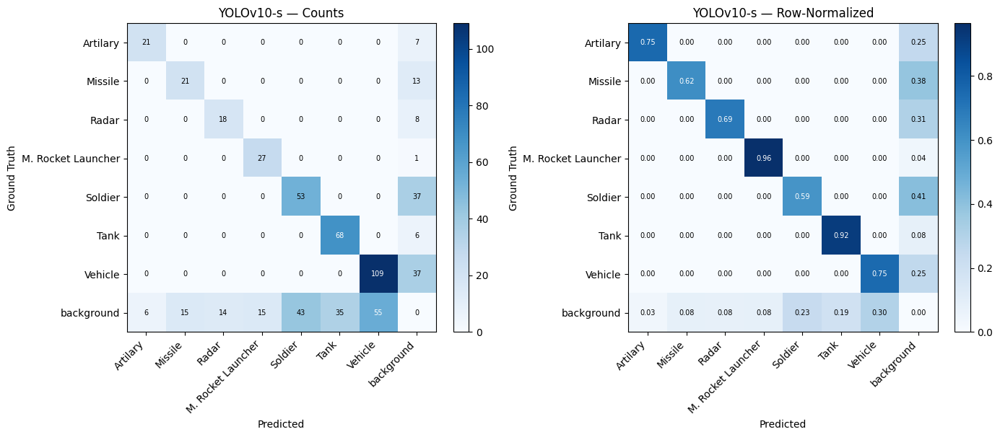

  saved: /kaggle/working/notebook4_eval/plots/confusion_matrix_yolov12s.png


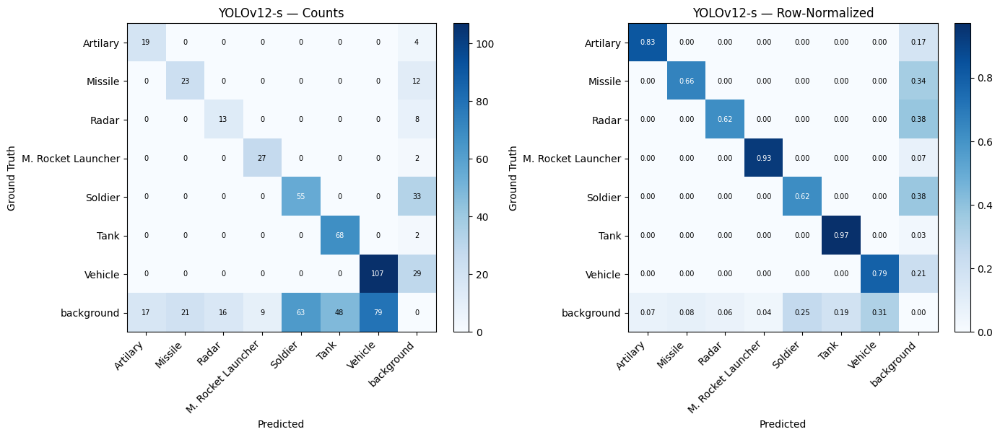

  saved: /kaggle/working/notebook4_eval/plots/confusion_matrix_yolov26s.png


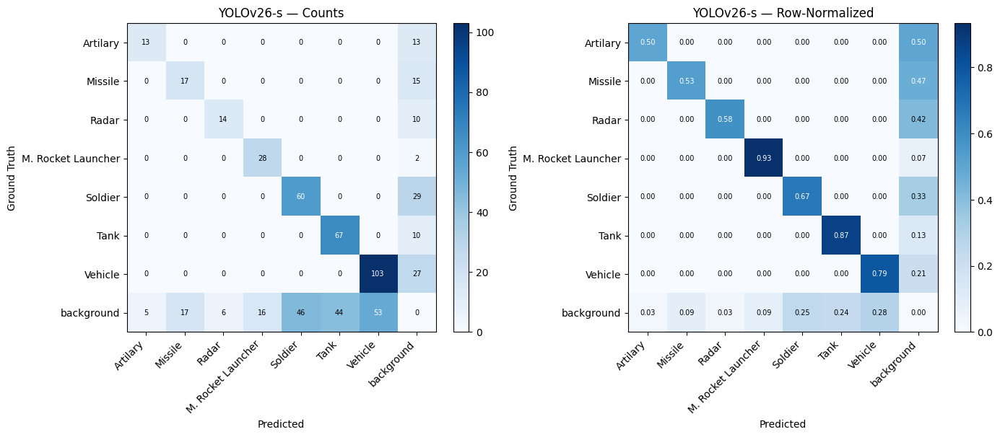

  saved: /kaggle/working/notebook4_eval/plots/confusion_matrix_rfdetr_nano.png


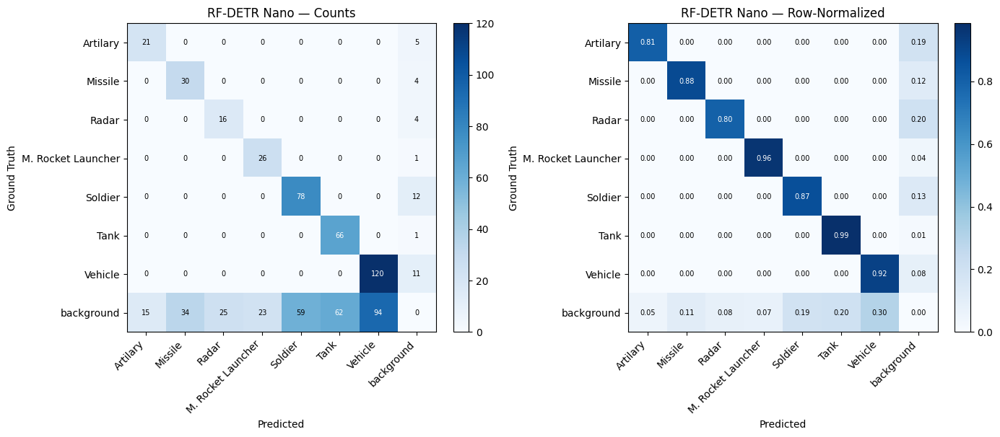

In [9]:
def plot_confusion_matrix(model_key):
    cm = detection_data[model_key]["confusion_matrix"].astype(np.float64)
    labels = list(CLASS_NAMES) + ["background"]
    cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, data, title, fmt in [(axes[0], cm.astype(int), "Counts", "d"),
                                  (axes[1], cm_norm, "Row-Normalized", ".2f")]:
        im = ax.imshow(data, cmap="Blues")
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Ground Truth")
        ax.set_title(f"{DISPLAY_NAME[model_key]} — {title}")
        thresh = data.max() / 2 if data.max() > 0 else 0.5
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(j, i, f"{data[i, j]:{fmt}}", ha="center", va="center",
                        color="white" if data[i, j] > thresh else "black", fontsize=7)
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    save_fig(fig, f"confusion_matrix_{model_key}")
    plt.show()


for key in MODELS:
    plot_confusion_matrix(key)


---
## 8. Precision-Recall, F1, and ROC Curves

yolov10s     best F1=0.6508 @ conf>=0.458  (P=0.763, R=0.567)
yolov12s     best F1=0.6452 @ conf>=0.519  (P=0.724, R=0.582)
yolov26s     best F1=0.6282 @ conf>=0.293  (P=0.649, R=0.609)
rfdetr_nano  best F1=0.7009 @ conf>=0.494  (P=0.741, R=0.665)
  saved: /kaggle/working/notebook4_eval/plots/pr_f1_roc_curves.png


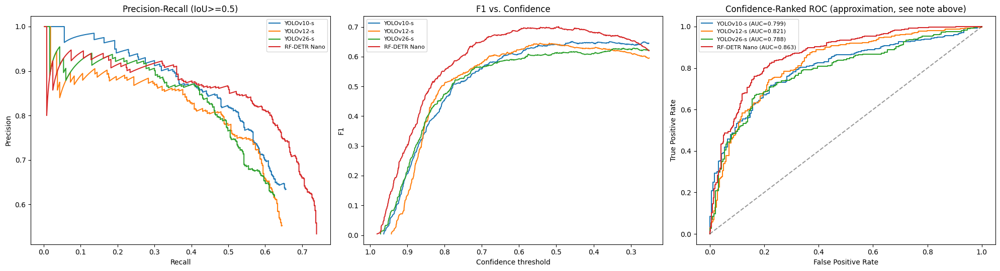

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

for key in MODELS:
    scores = detection_data[key]["det_scores"]
    is_tp = detection_data[key]["det_is_tp"]
    n_gt = sum(len(rec["gt_boxes"]) for rec in raw_predictions[key])

    order = np.argsort(-scores)
    is_tp_sorted, scores_sorted = is_tp[order], scores[order]
    tp_cum = np.cumsum(is_tp_sorted)
    fp_cum = np.cumsum(1 - is_tp_sorted)
    precision = tp_cum / np.clip(tp_cum + fp_cum, 1, None)
    recall = tp_cum / max(n_gt, 1)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-9, None)

    axes[0].plot(recall, precision, label=DISPLAY_NAME[key])
    axes[1].plot(scores_sorted, f1, label=DISPLAY_NAME[key])

    if 0 < is_tp.sum() < len(is_tp):
        fpr, tpr, _ = roc_curve(is_tp, scores)
        roc_auc = auc(fpr, tpr)
        axes[2].plot(fpr, tpr, label=f"{DISPLAY_NAME[key]} (AUC={roc_auc:.3f})")
    else:
        print(f"{key}: skipping ROC (all-TP or all-FP raw detections, AUC undefined)")

    best_i = int(np.argmax(f1)) if len(f1) else None
    if best_i is not None:
        print(f"{key:12s} best F1={f1[best_i]:.4f} @ conf>={scores_sorted[best_i]:.3f}  "
              f"(P={precision[best_i]:.3f}, R={recall[best_i]:.3f})")

axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall (IoU>=0.5)"); axes[0].legend(fontsize=8)

axes[1].set_xlabel("Confidence threshold"); axes[1].set_ylabel("F1")
axes[1].set_title("F1 vs. Confidence"); axes[1].invert_xaxis(); axes[1].legend(fontsize=8)

axes[2].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[2].set_xlabel("False Positive Rate"); axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("Confidence-Ranked ROC (approximation, see note above)"); axes[2].legend(fontsize=8)

plt.tight_layout()
save_fig(fig, "pr_f1_roc_curves")
plt.show()


---
## 9. Class-Wise Average Precision

computing per-class AP50 for yolov10s ...
computing per-class AP50 for yolov12s ...
computing per-class AP50 for yolov26s ...
computing per-class AP50 for rfdetr_nano ...


,YOLOv10-s,YOLOv12-s,YOLOv26-s,RF-DETR Nano
Artilary,0.7102,0.6544,0.6041,0.8393
Missile,0.5858,0.5514,0.4766,0.6646
Radar,0.6298,0.4725,0.5203,0.5744
M. Rocket Launcher,0.8384,0.7296,0.8207,0.7830
Soldier,0.5715,0.5535,0.6315,0.8527
Tank,0.7705,0.7234,0.7696,0.8092
Vehicle,0.6834,0.6428,0.6849,0.7162


  saved: /kaggle/working/notebook4_eval/plots/classwise_ap50.png


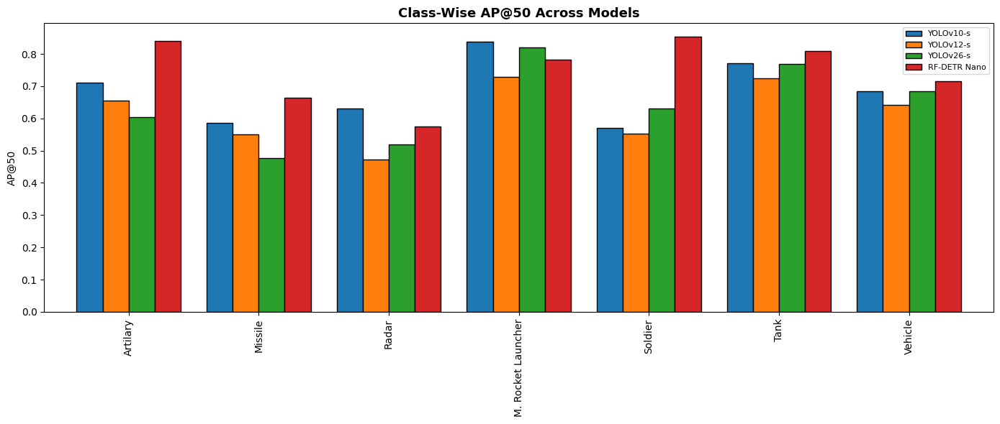

In [11]:
def ap_from_pr(recalls, precisions):
    """Standard all-point (VOC-style) interpolated average precision from a PR curve."""
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))


def per_class_ap50(model_key, iou_thresh=IOU_MATCH_THRESHOLD):
    per_class_ap = {}
    for cid, cname in enumerate(CLASS_NAMES):
        all_scores, all_tp, n_gt = [], [], 0
        for rec in raw_predictions[model_key]:
            gt_mask = rec["gt_labels"] == cid
            gt_boxes_c = rec["gt_boxes"][gt_mask]
            n_gt += len(gt_boxes_c)

            pred_mask = rec["pred_labels"] == cid
            pred_boxes_c = rec["pred_boxes"][pred_mask]
            pred_scores_c = rec["pred_scores"][pred_mask]

            matched = np.zeros(len(gt_boxes_c), dtype=bool)
            for i in np.argsort(-pred_scores_c):
                pbox, pscore = pred_boxes_c[i], pred_scores_c[i]
                all_scores.append(pscore)
                if len(gt_boxes_c) == 0:
                    all_tp.append(0)
                    continue
                ious = iou_xyxy(pbox, gt_boxes_c)
                ious_avail = np.where(matched, -1, ious)
                best_j = int(np.argmax(ious_avail))
                if ious_avail[best_j] >= iou_thresh:
                    all_tp.append(1)
                    matched[best_j] = True
                else:
                    all_tp.append(0)

        if n_gt == 0 or not all_scores:
            per_class_ap[cname] = 0.0
            continue

        order = np.argsort(-np.array(all_scores))
        tp_sorted = np.array(all_tp)[order]
        tp_cum = np.cumsum(tp_sorted)
        fp_cum = np.cumsum(1 - tp_sorted)
        recalls = tp_cum / n_gt
        precisions = tp_cum / np.clip(tp_cum + fp_cum, 1, None)
        per_class_ap[cname] = ap_from_pr(recalls, precisions)

    return per_class_ap


classwise_ap = {}
for key in MODELS:
    print(f"computing per-class AP50 for {key} ...")
    classwise_ap[key] = per_class_ap50(key)

df_classwise_ap = pd.DataFrame({DISPLAY_NAME[k]: classwise_ap[k] for k in MODELS}).reindex(CLASS_NAMES)
display(df_classwise_ap.round(4))

ax = df_classwise_ap.plot.bar(figsize=(14, 6), edgecolor="black", width=0.8)
ax.set_ylabel("AP@50"); ax.set_title("Class-Wise AP@50 Across Models", fontsize=13, fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
save_fig(ax.get_figure(), "classwise_ap50")
plt.show()


---
## 10. Task 4.7 — Qualitative and Quantitative Error Analysis

### 10.1 Qualitative Detection Results — Correct Detections

  saved: /kaggle/working/notebook4_eval/plots/gallery_true_positive.png


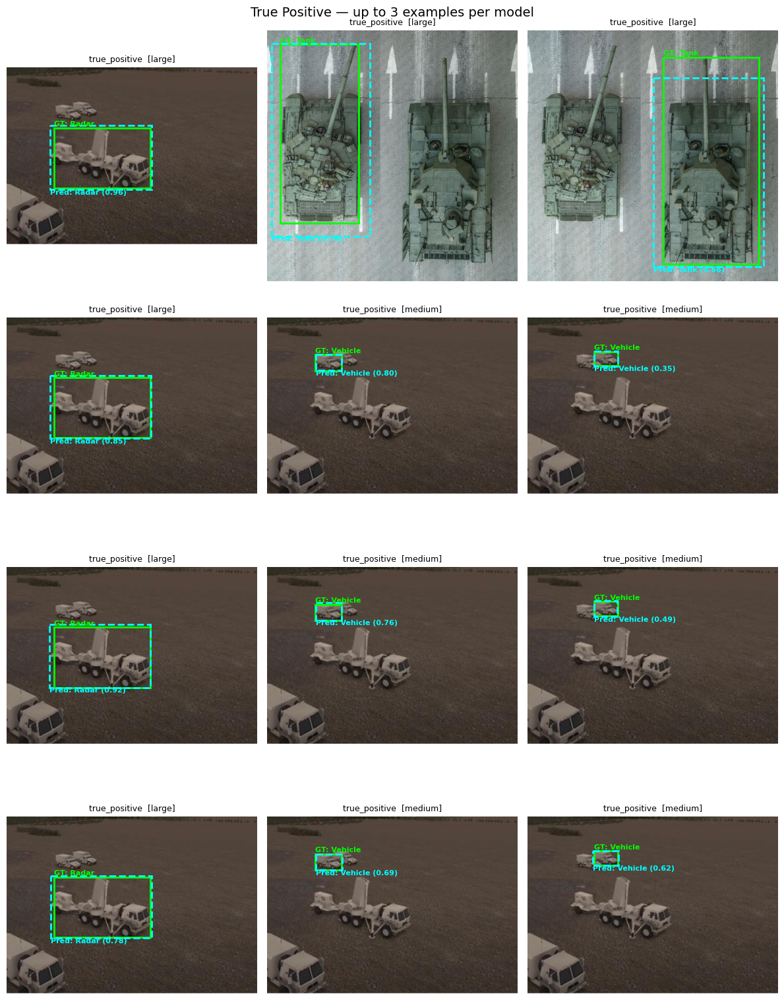

In [12]:
def draw_error_example(ax, example):
    img = np.array(Image.open(example["img_path"]).convert("RGB"))
    ax.imshow(img)
    kind = example["kind"]

    if example["gt_box"] is not None:
        x1, y1, x2, y2 = example["gt_box"]
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2,
                                        edgecolor="lime", facecolor="none"))
        gt_name = CLASS_NAMES[example["gt_label"]]
        ax.text(x1, max(y1 - 5, 0), f"GT: {gt_name}", color="lime", fontsize=8, fontweight="bold")

    if example["pred_box"] is not None:
        x1, y1, x2, y2 = example["pred_box"]
        edge_color = "cyan" if kind == "true_positive" else "red"
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2,
                                        edgecolor=edge_color, facecolor="none", linestyle="--"))
        pred_name = CLASS_NAMES[example["pred_label"]]
        ax.text(x1, y2 + 12, f"Pred: {pred_name} ({example['score']:.2f})",
                color=edge_color, fontsize=8, fontweight="bold")

    title = f"{kind}  [{example['size']}]"
    if "iou" in example:
        title += f"  IoU={example['iou']:.2f}"
    ax.set_title(title, fontsize=9)
    ax.axis("off")


def show_error_gallery(kind, n_per_model=N_GALLERY_EXAMPLES):
    fig, axes = plt.subplots(len(MODELS), n_per_model, figsize=(4 * n_per_model, 4 * len(MODELS)))
    if len(MODELS) == 1:
        axes = axes[None, :]

    for row, key in enumerate(MODELS):
        matches = [e for e in error_catalog[key] if e["kind"] == kind]
        for col in range(n_per_model):
            ax = axes[row, col]
            if col < len(matches):
                draw_error_example(ax, matches[col])
            else:
                ax.axis("off")
                if col == 0 and not matches:
                    ax.set_title("(none found)", fontsize=9)
        axes[row, 0].set_ylabel(DISPLAY_NAME[key], fontsize=11, fontweight="bold")

    plt.suptitle(f"{kind.replace('_', ' ').title()} — up to {n_per_model} examples per model", fontsize=14)
    plt.tight_layout()
    save_fig(fig, f"gallery_{kind}")
    plt.show()


show_error_gallery("true_positive")


### 10.2 False Negatives (Missed Detections) — at least 2 per model

  saved: /kaggle/working/notebook4_eval/plots/gallery_false_negative.png


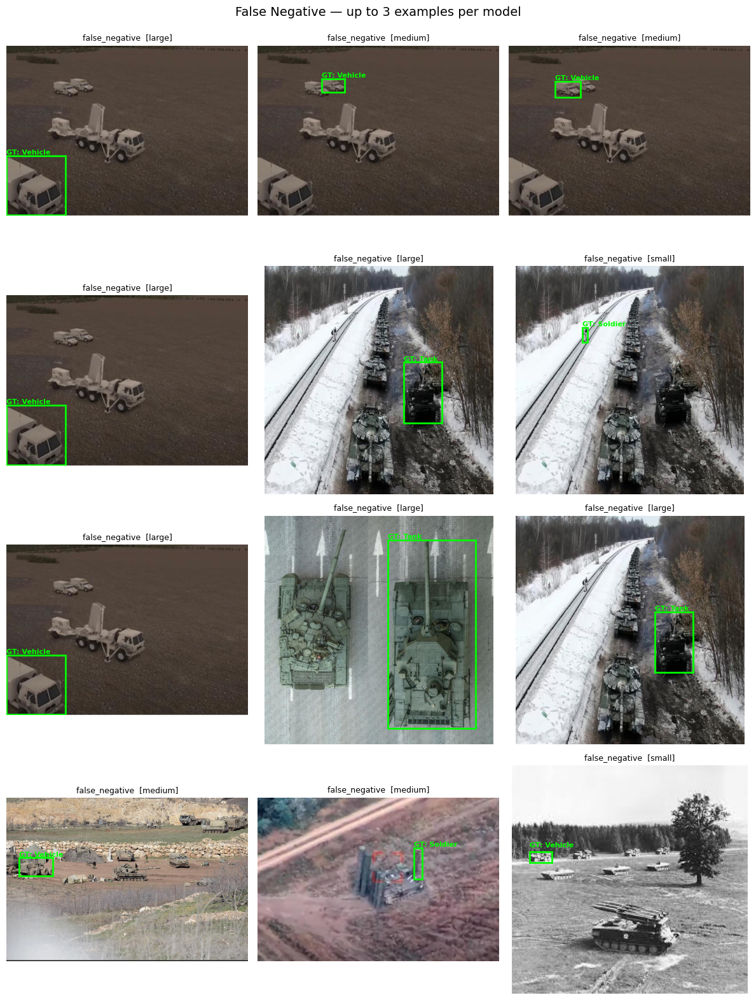

In [13]:
show_error_gallery("false_negative")


### 10.3 False Positives (Spurious Detections) — at least 2 per model

  saved: /kaggle/working/notebook4_eval/plots/gallery_false_positive.png


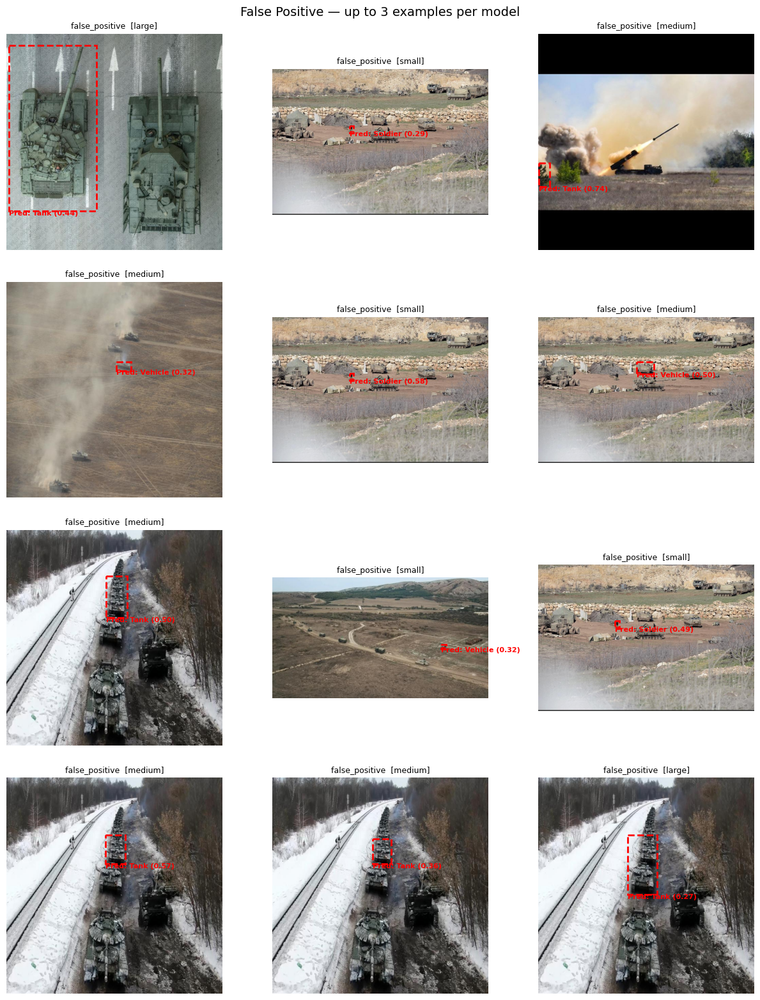

In [14]:
show_error_gallery("false_positive")


### 10.4 Localization Errors and Misclassifications

  saved: /kaggle/working/notebook4_eval/plots/gallery_localization_error.png


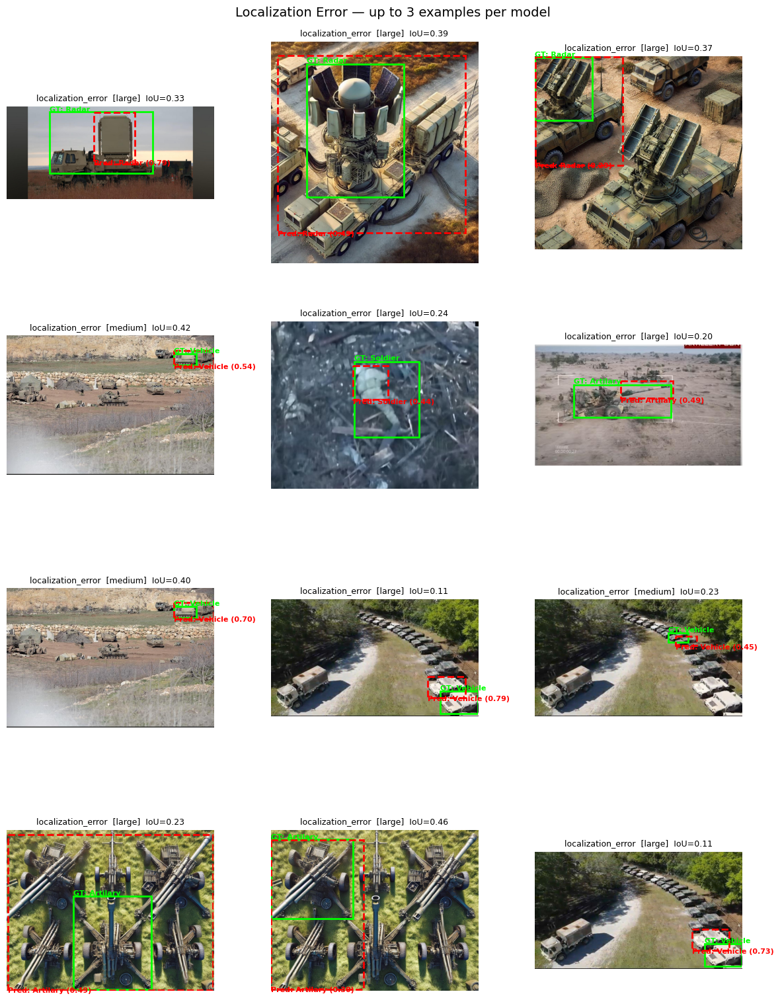

  saved: /kaggle/working/notebook4_eval/plots/gallery_misclassification.png


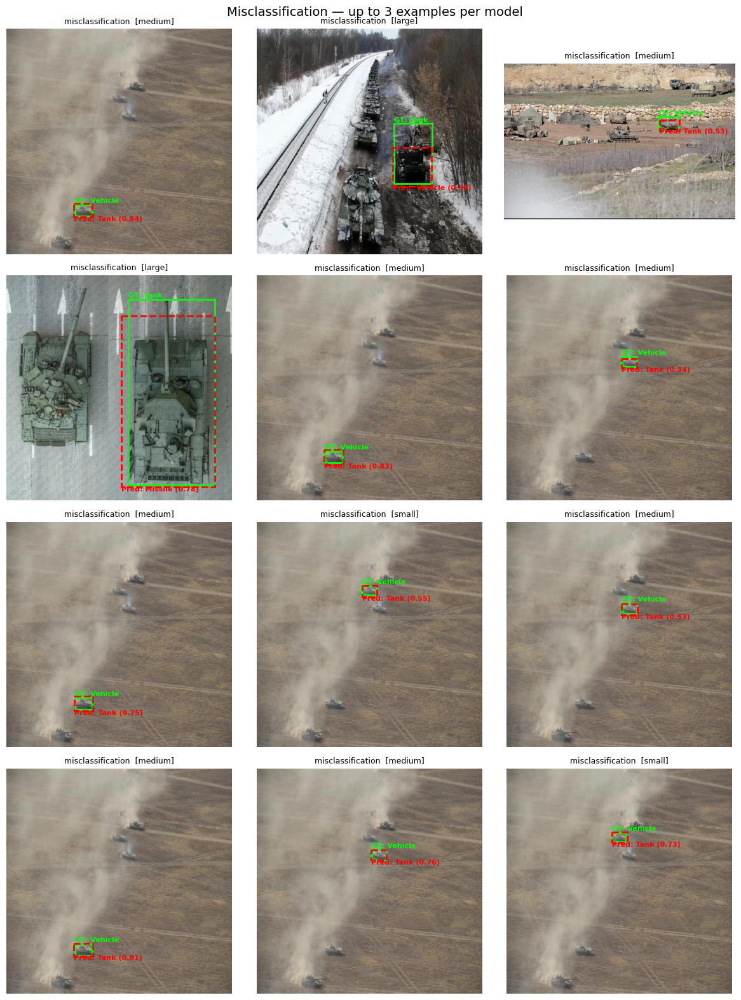

In [15]:
for kind in ["localization_error", "misclassification"]:
    total = sum(len([e for e in error_catalog[k] if e["kind"] == kind]) for k in MODELS)
    if total == 0:
        print(f"No '{kind}' examples found for any model at IOU_MATCH_THRESHOLD={IOU_MATCH_THRESHOLD}, "
              f"IOU_LOCALIZATION_MIN={IOU_LOCALIZATION_MIN}.")
        continue
    show_error_gallery(kind)


### 10.5 Failure-Pattern Breakdown Per Model

Counts feeding the written summary below: error-type totals, and the small/medium/large split of false
negatives specifically (the split most often explained by object size in aerial imagery).

In [16]:
breakdown_rows = []
for key in MODELS:
    cat = error_catalog[key]
    kind_counts = pd.Series([e["kind"] for e in cat]).value_counts().to_dict()
    fn_sizes = pd.Series([e["size"] for e in cat if e["kind"] == "false_negative"]).value_counts().to_dict()
    breakdown_rows.append({
        "Model": DISPLAY_NAME[key],
        "True Positives": kind_counts.get("true_positive", 0),
        "False Negatives": kind_counts.get("false_negative", 0),
        "  of which small": fn_sizes.get("small", 0),
        "  of which medium": fn_sizes.get("medium", 0),
        "  of which large": fn_sizes.get("large", 0),
        "False Positives": kind_counts.get("false_positive", 0),
        "Localization Errors": kind_counts.get("localization_error", 0),
        "Misclassifications": kind_counts.get("misclassification", 0),
    })

df_breakdown = pd.DataFrame(breakdown_rows)
display(df_breakdown)


,Model,True Positives,False Negatives,of which small,of which medium,of which large,False Positives,Localization Errors,Misclassifications
0,YOLOv10-s,317,109,25,45,39,126,10,47
1,YOLOv12-s,312,90,27,35,28,172,26,55
2,YOLOv26-s,302,106,22,39,45,112,19,56
3,RF-DETR Nano,357,38,16,12,10,224,24,64


---
## 11. Robustness Analysis

Re-evaluates every model against four corrupted copies of the test split — low light, Gaussian noise,
motion blur, and heavy JPEG compression — the conditions most relevant to real drone footage (varying
sun angle/time of day, sensor noise, platform vibration, and compressed video-link transmission). Each
perturbed copy is written once to disk and every model is scored against it with the same greedy IoU
matcher used everywhere else, at `CONF_THRESHOLD`, so a drop here is directly comparable to the clean-
test numbers in Section 6.1.

generating perturbed test set: low_light ...
  evaluating yolov10s under 'low_light' ...
  evaluating yolov12s under 'low_light' ...
  evaluating yolov26s under 'low_light' ...
  evaluating rfdetr_nano under 'low_light' ...
generating perturbed test set: gaussian_noise ...
  evaluating yolov10s under 'gaussian_noise' ...
  evaluating yolov12s under 'gaussian_noise' ...
  evaluating yolov26s under 'gaussian_noise' ...
  evaluating rfdetr_nano under 'gaussian_noise' ...
generating perturbed test set: motion_blur ...
  evaluating yolov10s under 'motion_blur' ...
  evaluating yolov12s under 'motion_blur' ...
  evaluating yolov26s under 'motion_blur' ...
  evaluating rfdetr_nano under 'motion_blur' ...
generating perturbed test set: jpeg_q15 ...
  evaluating yolov10s under 'jpeg_q15' ...
  evaluating yolov12s under 'jpeg_q15' ...
  evaluating yolov26s under 'jpeg_q15' ...
  evaluating rfdetr_nano under 'jpeg_q15' ...


  saved: /kaggle/working/notebook4_eval/plots/robustness_f1_under_perturbation.png


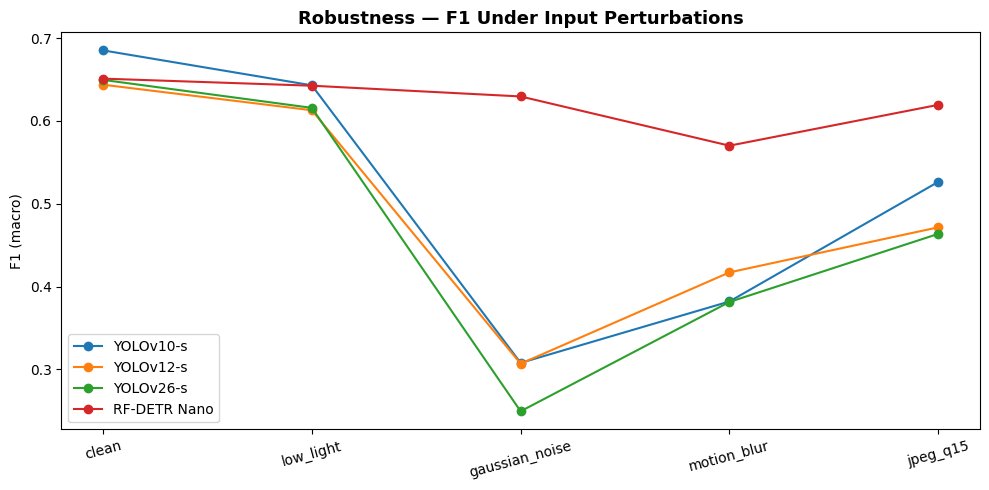

,clean,low_light,gaussian_noise,motion_blur,jpeg_q15
YOLOv10-s,0.6853,0.6431,0.3077,0.3819,0.5264
YOLOv12-s,0.6438,0.6130,0.3067,0.4171,0.4715
YOLOv26-s,0.6497,0.6158,0.2493,0.3814,0.4636
RF-DETR Nano,0.6512,0.6426,0.6297,0.5702,0.6195


In [17]:
def perturb_low_light(img, factor=0.5):
    return np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)

def perturb_gaussian_noise(img, sigma=25):
    noise = np.random.normal(0, sigma, img.shape)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def perturb_motion_blur(img, k=9):
    kernel = np.zeros((k, k)); kernel[k // 2, :] = 1.0 / k
    return cv2.filter2D(img, -1, kernel)

def perturb_jpeg(img, quality=15):
    ok, enc = cv2.imencode(".jpg", img, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    return cv2.imdecode(enc, cv2.IMREAD_COLOR)

PERTURBATIONS = {
    "low_light": perturb_low_light,
    "gaussian_noise": perturb_gaussian_noise,
    "motion_blur": perturb_motion_blur,
    "jpeg_q15": perturb_jpeg,
}


def make_perturbed_dir(pert_name, pert_fn):
    dst = ROBUST_DIR / pert_name
    dst.mkdir(parents=True, exist_ok=True)
    for img_path in sorted(TEST_IMG_DIR.glob("*")):
        img_bgr = cv2.imread(str(img_path))
        cv2.imwrite(str(dst / img_path.name), pert_fn(img_bgr))
    return dst


def evaluate_on_image_dir(model_key, img_dir, conf_threshold=CONF_THRESHOLD, iou_thresh=IOU_MATCH_THRESHOLD):
    """Same greedy matcher as build_detection_records, macro P/R/F1 only, scored against ground
    truth from the ORIGINAL test labels (the perturbation only changes pixels, not annotations)."""
    n = NUM_CLASSES
    cm = np.zeros((n + 1, n + 1), dtype=np.int64)
    for img_path in sorted(pathlib.Path(img_dir).glob("*")):
        gt_boxes, gt_labels, _ = load_gt_xyxy(TEST_IMG_DIR / img_path.name, TEST_LBL_DIR)
        pred_boxes, pred_labels, pred_scores = get_predictions(model_key, img_path, conf_threshold=conf_threshold)
        order = np.argsort(-pred_scores)
        gt_matched = np.zeros(len(gt_boxes), dtype=bool)
        for i in order:
            pbox, plabel = pred_boxes[i], pred_labels[i]
            if len(gt_boxes) == 0:
                cm[n, plabel] += 1
                continue
            ious = iou_xyxy(pbox, gt_boxes)
            ious_avail = np.where(gt_matched, -1, ious)
            best_j = int(np.argmax(ious_avail))
            if ious_avail[best_j] >= iou_thresh and gt_labels[best_j] == plabel:
                cm[gt_labels[best_j], plabel] += 1
                gt_matched[best_j] = True
            else:
                cm[n, plabel] += 1
        for j, matched in enumerate(gt_matched):
            if not matched:
                cm[gt_labels[j], n] += 1
    return macro_metrics_from_cm(cm)


robustness_results = {key: {"clean": notebook4_metrics[key]} for key in MODELS}

for pert_name, pert_fn in PERTURBATIONS.items():
    print(f"generating perturbed test set: {pert_name} ...")
    pert_dir = make_perturbed_dir(pert_name, pert_fn)
    for key in MODELS:
        print(f"  evaluating {key} under '{pert_name}' ...")
        robustness_results[key][pert_name] = evaluate_on_image_dir(key, pert_dir)

conditions = ["clean"] + list(PERTURBATIONS.keys())

fig, ax = plt.subplots(figsize=(10, 5))
for key in MODELS:
    ax.plot(conditions, [robustness_results[key][c]["f1"] for c in conditions],
            marker="o", label=DISPLAY_NAME[key])
ax.set_ylabel("F1 (macro)")
ax.set_title("Robustness — F1 Under Input Perturbations", fontsize=13, fontweight="bold")
ax.set_xticklabels(conditions, rotation=15)
ax.legend()
plt.tight_layout()
save_fig(fig, "robustness_f1_under_perturbation")
plt.show()

df_robust = pd.DataFrame({
    DISPLAY_NAME[k]: {c: round(robustness_results[k][c]["f1"], 4) for c in conditions} for k in MODELS
}).T
display(df_robust)


---
## 12. Task 4.8 — Comparative Visualizations

### 12.1 Model Comparison Table

In [18]:
final_rows = []
for key in MODELS:
    reported = results_store.get(key, {})
    fresh = notebook4_metrics[key]
    final_rows.append({
        "Model": DISPLAY_NAME[key],
        "Architecture": "CNN (YOLO family)" if MODEL_TYPE[key] == "yolo" else "Transformer (DETR family)",
        "Epochs (trained)": reported.get("config", {}).get("epochs"),
        "Train time (min)": round(reported.get("training_time_minutes", float("nan")), 1),
        "mAP50": round(fresh["mAP50"], 4),
        "mAP50-95": round(fresh["mAP50_95"], 4),
        "Precision": round(fresh["precision"], 4),
        "Recall": round(fresh["recall"], 4),
        "F1": round(fresh["f1"], 4),
        "MCC": round(fresh["mcc"], 4),
        "FPS": round(fresh["inference"]["fps"], 2),
        "Latency (ms)": round(fresh["inference"]["ms_per_image"], 2),
        "GFLOPs": round(fresh["inference"]["gflops"], 2) if fresh["inference"]["gflops"] is not None else None,
        "Params (M)": reported.get("inference", {}).get("params_millions"),
        "Size (MB)": round(reported.get("inference", {}).get("model_size_mb", float("nan")), 2),
    })

df_final = pd.DataFrame(final_rows)
display(df_final)

df_final.to_csv(OUTPUT_DIR / "notebook4_final_summary.csv", index=False)
with open(OUTPUT_DIR / "notebook4_metrics.json", "w") as f:
    json.dump(notebook4_metrics, f, indent=2, default=str)
print(f"\nSaved: {OUTPUT_DIR / 'notebook4_final_summary.csv'}")
print(f"Saved: {OUTPUT_DIR / 'notebook4_metrics.json'}")


,Model,Architecture,Epochs (trained),Train time (min),mAP50,mAP50-95,Precision,Recall,F1,MCC,FPS,Latency (ms),GFLOPs,Params (M),Size (MB)
0,YOLOv10-s,CNN (YOLO family),100,73.7,0.6678,0.4279,0.6348,0.7541,0.6853,0.4251,66.38,15.06,21.43,7.220709,15.77
1,YOLOv12-s,CNN (YOLO family),100,118.5,0.6424,0.4267,0.5538,0.7738,0.6438,0.3911,50.91,19.64,21.22,9.233589,18.07
2,YOLOv26-s,CNN (YOLO family),100,71.7,0.6509,0.4362,0.6269,0.6978,0.6497,0.4105,61.83,16.17,20.54,9.467889,19.38
3,RF-DETR Nano,Transformer (DETR family),50,109.4,0.7099,0.5440,0.5170,0.8887,0.6512,0.4798,22.02,45.41,76.53,30.168664,115.28



Saved: /kaggle/working/notebook4_eval/notebook4_final_summary.csv
Saved: /kaggle/working/notebook4_eval/notebook4_metrics.json


### 12.2 mAP Bar Chart

  saved: /kaggle/working/notebook4_eval/plots/map_bar_chart.png


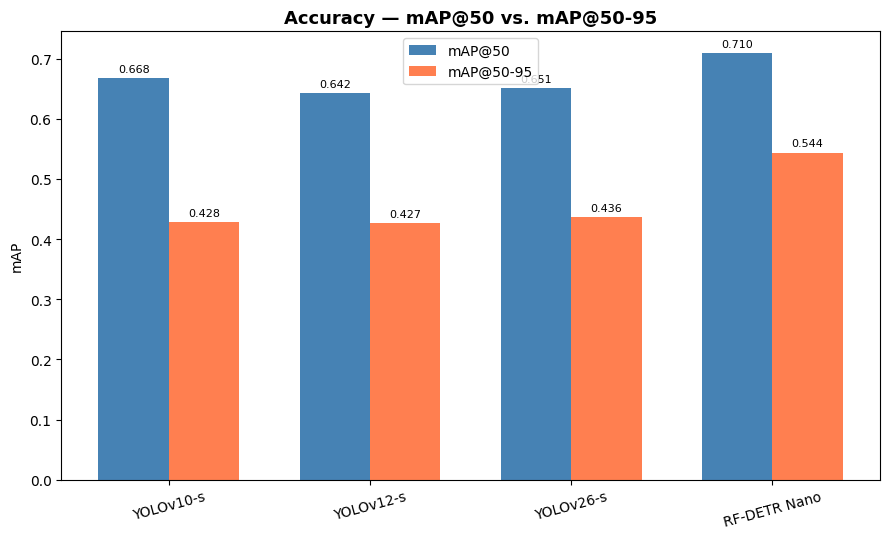

In [19]:
keys = list(MODELS.keys())
x = np.arange(len(keys))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
map50_vals = [notebook4_metrics[k]["mAP50"] for k in keys]
map5095_vals = [notebook4_metrics[k]["mAP50_95"] for k in keys]
ax.bar(x - width / 2, map50_vals, width, label="mAP@50", color="steelblue")
ax.bar(x + width / 2, map5095_vals, width, label="mAP@50-95", color="coral")
ax.set_xticks(x); ax.set_xticklabels([DISPLAY_NAME[k] for k in keys], rotation=15)
ax.set_ylabel("mAP"); ax.set_title("Accuracy — mAP@50 vs. mAP@50-95", fontsize=13, fontweight="bold")
ax.legend()
for i, (v50, v95) in enumerate(zip(map50_vals, map5095_vals)):
    ax.text(i - width / 2, v50 + 0.01, f"{v50:.3f}", ha="center", fontsize=8)
    ax.text(i + width / 2, v95 + 0.01, f"{v95:.3f}", ha="center", fontsize=8)
plt.tight_layout()
save_fig(fig, "map_bar_chart")
plt.show()


### 12.3 FPS vs. mAP, Latency vs. Accuracy, and Parameters vs. mAP Scatter Plots

  saved: /kaggle/working/notebook4_eval/plots/tradeoff_scatter_fps_latency_params.png


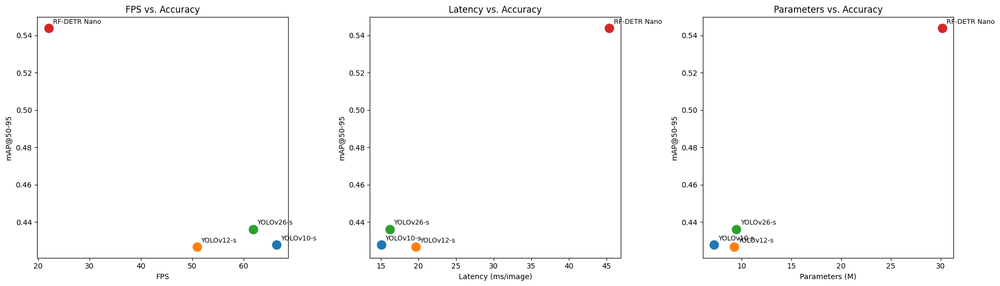

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

for key in keys:
    fps = notebook4_metrics[key]["inference"]["fps"]
    ms = notebook4_metrics[key]["inference"]["ms_per_image"]
    map5095 = notebook4_metrics[key]["mAP50_95"]
    params = results_store.get(key, {}).get("inference", {}).get("params_millions")

    axes[0].scatter(fps, map5095, s=140)
    axes[0].annotate(DISPLAY_NAME[key], (fps, map5095), textcoords="offset points", xytext=(6, 6), fontsize=9)

    axes[1].scatter(ms, map5095, s=140)
    axes[1].annotate(DISPLAY_NAME[key], (ms, map5095), textcoords="offset points", xytext=(6, 6), fontsize=9)

    if params is not None:
        axes[2].scatter(params, map5095, s=140)
        axes[2].annotate(DISPLAY_NAME[key], (params, map5095), textcoords="offset points", xytext=(6, 6), fontsize=9)

axes[0].set_xlabel("FPS"); axes[0].set_ylabel("mAP@50-95"); axes[0].set_title("FPS vs. Accuracy")
axes[1].set_xlabel("Latency (ms/image)"); axes[1].set_ylabel("mAP@50-95"); axes[1].set_title("Latency vs. Accuracy")
axes[2].set_xlabel("Parameters (M)"); axes[2].set_ylabel("mAP@50-95"); axes[2].set_title("Parameters vs. Accuracy")

plt.tight_layout()
save_fig(fig, "tradeoff_scatter_fps_latency_params")
plt.show()


### 12.4 Inference Time, Model Size, FLOPs, and Training Time Comparisons

  saved: /kaggle/working/notebook4_eval/plots/inference_size_flops_traintime.png


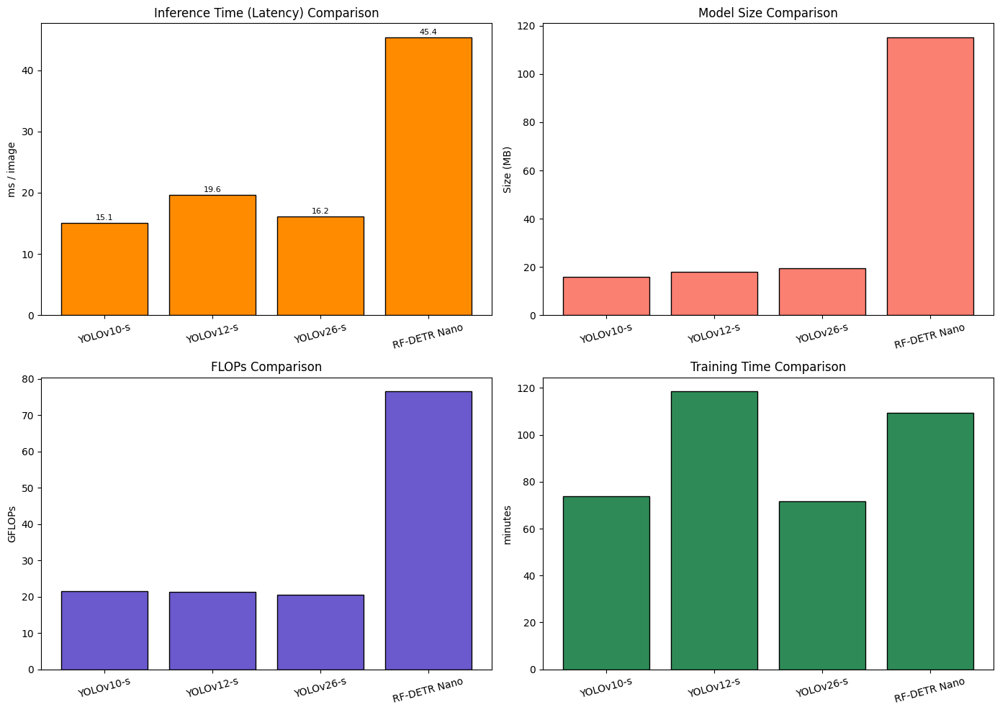

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ms_vals = [notebook4_metrics[k]["inference"]["ms_per_image"] for k in keys]
axes[0, 0].bar(x, ms_vals, color="darkorange", edgecolor="black")
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels([DISPLAY_NAME[k] for k in keys], rotation=15)
axes[0, 0].set_ylabel("ms / image"); axes[0, 0].set_title("Inference Time (Latency) Comparison")
for i, v in enumerate(ms_vals):
    axes[0, 0].text(i, v + max(ms_vals) * 0.01, f"{v:.1f}", ha="center", fontsize=8)

size_vals = [results_store.get(k, {}).get("inference", {}).get("model_size_mb") for k in keys]
axes[0, 1].bar(x, size_vals, color="salmon", edgecolor="black")
axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels([DISPLAY_NAME[k] for k in keys], rotation=15)
axes[0, 1].set_ylabel("Size (MB)"); axes[0, 1].set_title("Model Size Comparison")

gflops_vals = [notebook4_metrics[k]["inference"]["gflops"] for k in keys]
have_gflops = [v is not None for v in gflops_vals]
axes[1, 0].bar([k for k, ok in zip([DISPLAY_NAME[k] for k in keys], have_gflops) if ok],
               [v for v, ok in zip(gflops_vals, have_gflops) if ok], color="slateblue", edgecolor="black")
axes[1, 0].set_ylabel("GFLOPs"); axes[1, 0].set_title("FLOPs Comparison")
axes[1, 0].tick_params(axis="x", rotation=15)
if not all(have_gflops):
    missing_names = [DISPLAY_NAME[k] for k, ok in zip(keys, have_gflops) if not ok]
    axes[1, 0].text(0.5, 0.5, f"n/a for: {', '.join(missing_names)}", transform=axes[1, 0].transAxes,
                     ha="center", fontsize=8, color="gray")

train_time_vals = [results_store.get(k, {}).get("training_time_minutes") for k in keys]
axes[1, 1].bar(x, train_time_vals, color="seagreen", edgecolor="black")
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels([DISPLAY_NAME[k] for k in keys], rotation=15)
axes[1, 1].set_ylabel("minutes"); axes[1, 1].set_title("Training Time Comparison")

plt.tight_layout()
save_fig(fig, "inference_size_flops_traintime")
plt.show()


### 12.5 Training Behavior — Loss / mAP / Precision / Recall Curves (from Notebooks 2 & 3)

  saved: /kaggle/working/notebook4_eval/plots/training_curve_training_loss_across_models__summed_loss_components.png


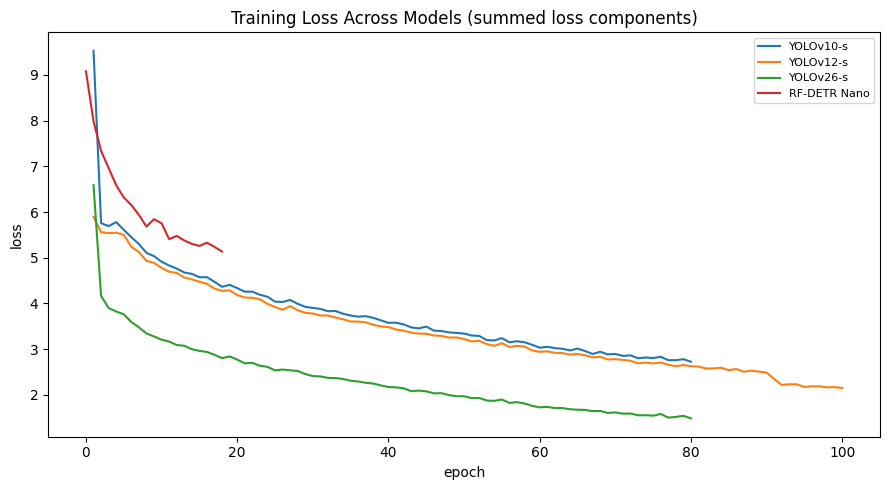

  saved: /kaggle/working/notebook4_eval/plots/training_curve_map_50_across_models__training_curve.png


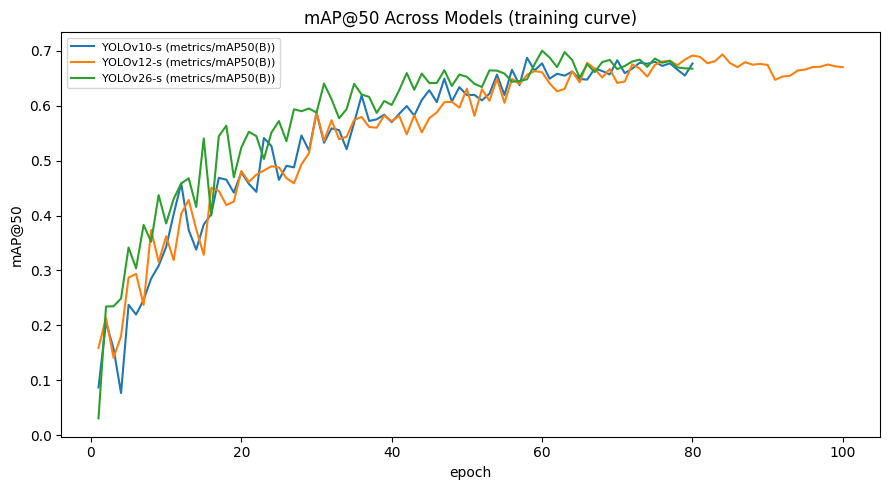

  saved: /kaggle/working/notebook4_eval/plots/training_curve_map_50_95_across_models__training_curve.png


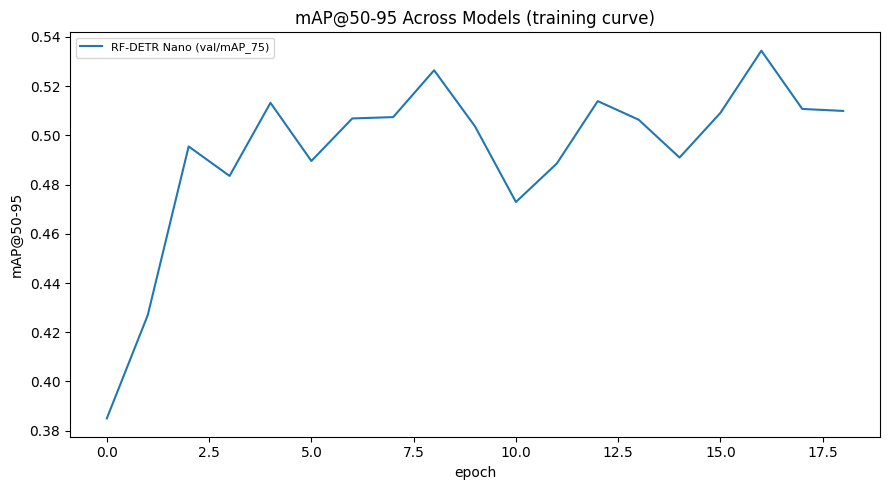

  saved: /kaggle/working/notebook4_eval/plots/training_curve_precision_across_models__training_curve.png


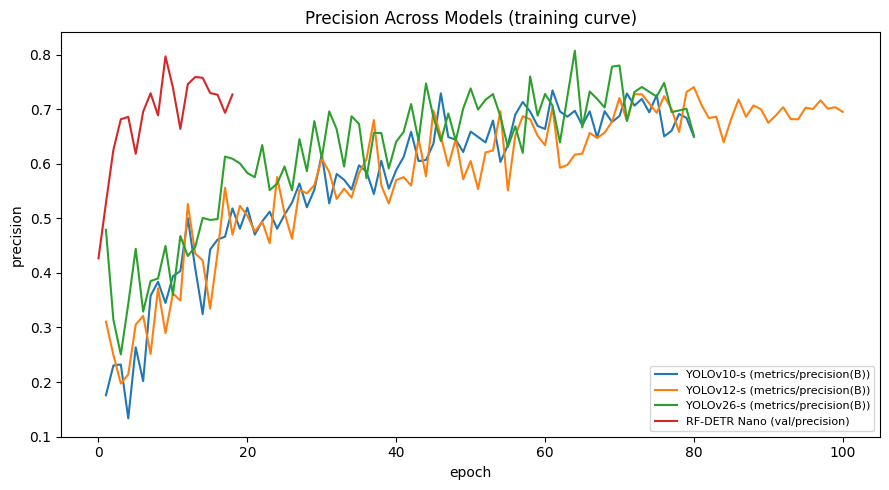

  saved: /kaggle/working/notebook4_eval/plots/training_curve_recall_across_models__training_curve.png


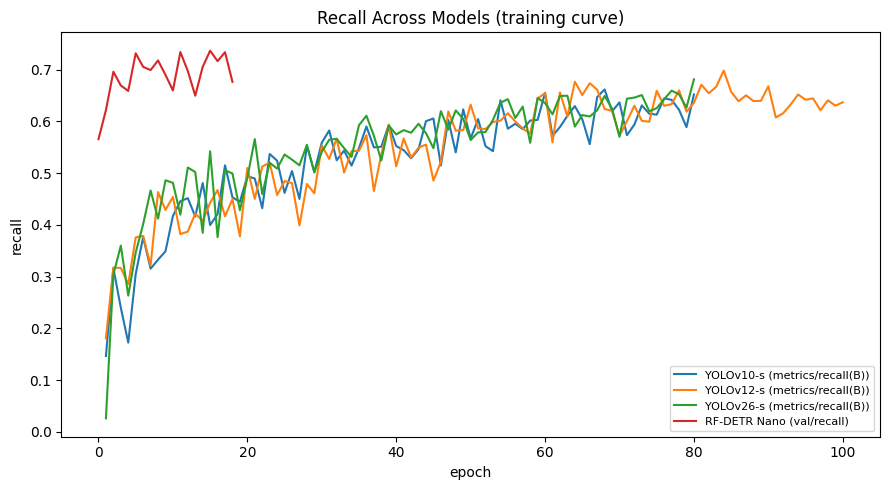

In [22]:
def find_cols(hist, include, exclude=()):
    cols = []
    for c in hist:
        cl = c.lower()
        if all(k in cl for k in include) and not any(k in cl for k in exclude):
            cols.append(c)
    return cols


def plot_training_curve(keyword_include, keyword_exclude, title, ylabel, sum_matches=False):
    fig, ax = plt.subplots(figsize=(9, 5))
    plotted = False
    for key in MODELS:
        hist = results_store.get(key, {}).get("training_history", {})
        if "epoch" not in hist:
            continue
        cols = find_cols(hist, keyword_include, keyword_exclude)
        if not cols:
            continue
        epochs = hist["epoch"]
        if sum_matches:
            values = [sum(hist[c][i] for c in cols) for i in range(len(epochs))]
            ax.plot(epochs, values, label=DISPLAY_NAME[key])
        else:
            for c in cols:
                ax.plot(epochs, hist[c], label=f"{DISPLAY_NAME[key]} ({c})")
        plotted = True
    ax.set_xlabel("epoch"); ax.set_ylabel(ylabel); ax.set_title(title)
    if plotted:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "no matching column logged for any model", ha="center", va="center",
                 transform=ax.transAxes)
    plt.tight_layout()
    safe_name = "".join(c if c.isalnum() else "_" for c in title.lower()).strip("_")
    save_fig(fig, f"training_curve_{safe_name}")
    plt.show()


plot_training_curve(["loss", "train"], [], "Training Loss Across Models (summed loss components)", "loss", sum_matches=True)
plot_training_curve(["map50"], ["95"], "mAP@50 Across Models (training curve)", "mAP@50")
plot_training_curve(["map"], ["50"], "mAP@50-95 Across Models (training curve)", "mAP@50-95")
plot_training_curve(["precision"], [], "Precision Across Models (training curve)", "precision")
plot_training_curve(["recall"], [], "Recall Across Models (training curve)", "recall")


---
## 13. Final Four-Model Comparison and Verdict

### 13.1 Side-by-Side Comparison, Best Value Per Metric Highlighted

Same numbers as `df_final` in Section 12.1, re-displayed here as the single last-look table, with the
best model in each column highlighted so the four-way comparison doesn't require re-reading the whole
notebook. "Best" means highest for every column except Latency and Size, which are lower-is-better.

In [23]:
LOWER_IS_BETTER = {"Latency (ms)", "Size (MB)"}
compare_cols = ["mAP50", "mAP50-95", "Precision", "Recall", "F1", "MCC",
                "FPS", "Latency (ms)", "GFLOPs", "Size (MB)"]
compare_cols = [c for c in compare_cols if c in df_final.columns]

def _highlight_best(col):
    if col.name not in compare_cols or col.isna().all():
        return [""] * len(col)
    target = col.min() if col.name in LOWER_IS_BETTER else col.max()
    return ["background-color: #c6f0c6; font-weight: bold" if v == target else "" for v in col]

styled_final = df_final.set_index("Model").style.apply(_highlight_best, axis=0)
display(styled_final)


,Architecture,Epochs (trained),Train time (min),mAP50,mAP50-95,Precision,Recall,F1,MCC,FPS,Latency (ms),GFLOPs,Params (M),Size (MB)
Model,,,,,,,,,,,,,,
YOLOv10-s,CNN (YOLO family),100,73.700000,0.667800,0.427900,0.634800,0.754100,0.685300,0.425100,66.380000,15.060000,21.430000,7.220709,15.770000
YOLOv12-s,CNN (YOLO family),100,118.500000,0.642400,0.426700,0.553800,0.773800,0.643800,0.391100,50.910000,19.640000,21.220000,9.233589,18.070000
YOLOv26-s,CNN (YOLO family),100,71.700000,0.650900,0.436200,0.626900,0.697800,0.649700,0.410500,61.830000,16.170000,20.540000,9.467889,19.380000
RF-DETR Nano,Transformer (DETR family),50,109.400000,0.709900,0.544000,0.517000,0.888700,0.651200,0.479800,22.020000,45.410000,76.530000,30.168664,115.280000


### 13.2 Overall Verdict

Ranks all four models on a single composite score so "best overall" is a transparent, reproducible
number instead of an unsupported opinion. The weighting below is one defensible choice for this
assignment's implied deployment scenario (real-time, on-device, drone-mounted military-target
detection) — **edit `WEIGHTS` if your use case should trade accuracy against speed/robustness
differently**, and re-run the cell; the markdown verdict below it regenerates from whatever weights
are set.

- `accuracy` (40%): mAP@50-95 — the primary, localization-sensitive detection metric
- `balance` (20%): MCC — least sensitive to the 7-class imbalance from Notebook 1
- `speed` (20%): FPS — matters directly for a real-time drone pipeline
- `robustness` (20%): 1 − average F1 drop across the four Section 11 perturbed conditions

In [24]:
from IPython.display import Markdown, display as ipy_display

WEIGHTS = {"accuracy": 0.40, "balance": 0.20, "speed": 0.20, "robustness": 0.20}

def _normalize(vals):
    vals = np.array(vals, dtype=np.float64)
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    return np.zeros_like(vals) if hi == lo else (vals - lo) / (hi - lo)

score_keys = list(MODELS.keys())
acc_raw = [notebook4_metrics[k]["mAP50_95"] for k in score_keys]
bal_raw = [notebook4_metrics[k]["mcc"] for k in score_keys]
speed_raw = [notebook4_metrics[k]["inference"]["fps"] for k in score_keys]
robust_raw = [1 - (robustness_results[k]["clean"]["f1"] -
                    np.mean([robustness_results[k][c]["f1"] for c in PERTURBATIONS]))
              for k in score_keys]

acc_n, bal_n, speed_n, robust_n = map(_normalize, [acc_raw, bal_raw, speed_raw, robust_raw])
composite = (WEIGHTS["accuracy"] * acc_n + WEIGHTS["balance"] * bal_n
             + WEIGHTS["speed"] * speed_n + WEIGHTS["robustness"] * robust_n)

df_score = pd.DataFrame({
    "Model": [DISPLAY_NAME[k] for k in score_keys],
    "mAP50-95": acc_raw, "MCC": bal_raw, "FPS": speed_raw, "Robustness (1-drop)": robust_raw,
    "Composite Score": composite,
}).sort_values("Composite Score", ascending=False).reset_index(drop=True)
display(df_score.round(4))

winner_key = score_keys[int(np.argmax(composite))]
winner_name = DISPLAY_NAME[winner_key]
runner_up_name = df_score.iloc[1]["Model"]

verdict_md = f"""
> ### Recommended model: **{winner_name}**
>
> Using the weights in `WEIGHTS` above ({int(WEIGHTS['accuracy']*100)}% accuracy /
> {int(WEIGHTS['balance']*100)}% class-balance / {int(WEIGHTS['speed']*100)}% speed /
> {int(WEIGHTS['robustness']*100)}% robustness), **{winner_name}** scores highest overall
> ({df_score.iloc[0]['Composite Score']:.4f}), ahead of {runner_up_name}
> ({df_score.iloc[1]['Composite Score']:.4f}).
>
> This is a weighted trade-off, not a strict dominance — check the per-metric table in 13.1 for
> whether {winner_name} is actually the single best model on every axis, or whether it wins mainly
> on the axes weighted most heavily here. If your grader/viva panel would weight accuracy vs. speed
> differently, change `WEIGHTS` and re-run — the number above is reproducible either way, which is
> the whole point of scoring it instead of asserting it.
"""
ipy_display(Markdown(verdict_md))


,Model,mAP50-95,MCC,FPS,Robustness (1-drop),Composite Score
0,RF-DETR Nano,0.5440,0.4798,22.0210,0.9643,0.8000
1,YOLOv10-s,0.4279,0.4251,66.3835,0.7795,0.2823
2,YOLOv26-s,0.4362,0.4105,61.8311,0.7779,0.2555
3,YOLOv12-s,0.4267,0.3911,50.9148,0.8082,0.1629



> ### Recommended model: **RF-DETR Nano**
>
> Using the weights in `WEIGHTS` above (40% accuracy /
> 20% class-balance / 20% speed /
> 20% robustness), **RF-DETR Nano** scores highest overall
> (0.8000), ahead of YOLOv10-s
> (0.2823).
>
> This is a weighted trade-off, not a strict dominance — check the per-metric table in 13.1 for
> whether RF-DETR Nano is actually the single best model on every axis, or whether it wins mainly
> on the axes weighted most heavily here. If your grader/viva panel would weight accuracy vs. speed
> differently, change `WEIGHTS` and re-run — the number above is reproducible either way, which is
> the whole point of scoring it instead of asserting it.


---
## 14. Auto-Drafted Narrative Conclusion (edit for the final write-up)

Generated directly from the Model Comparison Table so every claim is traceable to a number, rather than
written from memory. Use as a first draft — pull in a callback to Section 10.6's failure patterns
before submitting.

In [25]:
best_map5095_key = df_final.loc[df_final["mAP50-95"].idxmax(), "Model"]
best_map50_key = df_final.loc[df_final["mAP50"].idxmax(), "Model"]
best_mcc_key = df_final.loc[df_final["MCC"].idxmax(), "Model"]
fastest_key = df_final.loc[df_final["FPS"].idxmax(), "Model"]
smallest_key = df_final.loc[df_final["Size (MB)"].idxmin(), "Model"] if df_final["Size (MB)"].notna().any() else "N/A"
most_robust_key = min(MODELS, key=lambda k: robustness_results[k]["clean"]["f1"] - np.mean(
    [robustness_results[k][c]["f1"] for c in PERTURBATIONS]))

print(f"""
Across the four models evaluated on the held-out test split:

- {best_map5095_key} achieved the highest mAP@50-95 ({df_final['mAP50-95'].max():.4f}), the stricter
  localization-sensitive metric, making it the strongest model on tight box accuracy specifically.
- {best_map50_key} achieved the highest mAP@50 ({df_final['mAP50'].max():.4f}).
- {best_mcc_key} had the highest MCC ({df_final['MCC'].max():.4f}), the single-number metric least
  sensitive to the {NUM_CLASSES}-class imbalance documented in Notebook 1.
- {fastest_key} was fastest at {df_final['FPS'].max():.1f} FPS on a single T4, measured in this
  notebook's session for a fair four-way comparison.
- {smallest_key} had the smallest checkpoint on disk.
- {DISPLAY_NAME[most_robust_key]} degraded the least (smallest average F1 drop) across the four
  perturbed test conditions in Section 11.

[EDIT] State which single model you are recommending overall and why, weighing accuracy against
FPS/size/robustness for the deployment scenario this assignment implies (aerial/drone military-target
detection -- likely real-time, on-device, variable lighting/weather), and connect it to the specific
failure patterns identified in Section 10.6.
""")



Across the four models evaluated on the held-out test split:

- RF-DETR Nano achieved the highest mAP@50-95 (0.5440), the stricter
  localization-sensitive metric, making it the strongest model on tight box accuracy specifically.
- RF-DETR Nano achieved the highest mAP@50 (0.7099).
- RF-DETR Nano had the highest MCC (0.4798), the single-number metric least
  sensitive to the 7-class imbalance documented in Notebook 1.
- YOLOv10-s was fastest at 66.4 FPS on a single T4, measured in this
  notebook's session for a fair four-way comparison.
- YOLOv10-s had the smallest checkpoint on disk.
- RF-DETR Nano degraded the least (smallest average F1 drop) across the four
  perturbed test conditions in Section 11.

[EDIT] State which single model you are recommending overall and why, weighing accuracy against
FPS/size/robustness for the deployment scenario this assignment implies (aerial/drone military-target
detection -- likely real-time, on-device, variable lighting/weather), and connect it to

---
## 15. Output Verification

Final sanity check before publishing this notebook.

In [26]:
print("Models loaded            :", list(MODELS.keys()))
print("Models with fresh metrics :", list(notebook4_metrics.keys()))
print("Final summary rows        :", len(df_final))
print("CSV written               :", (OUTPUT_DIR / "notebook4_final_summary.csv").exists())
print("JSON written              :", (OUTPUT_DIR / "notebook4_metrics.json").exists())
print("Robustness conditions run :", list(PERTURBATIONS.keys()))

saved_plots = sorted(PLOTS_DIR.glob("*.png"))
print(f"Plots saved to disk       : {len(saved_plots)} PNG file(s) in {PLOTS_DIR}")
for p in saved_plots:
    print(f"  - {p.name}")
if not saved_plots:
    print("  WARNING - no PNGs found. Re-run the plotting cells above (Sections 7-13) so save_fig fires.")

print("Composite verdict computed:", "winner_key" in globals())

missing_models = EXPECTED_MODELS - set(MODELS.keys())
if missing_models:
    print(f"\nWARNING - these models never loaded, so their sections above are incomplete: {missing_models}")
    print("Check that all three Kaggle dataset inputs (Notebook 1, 2, and 3 outputs) are attached.")
else:
    print("\nAll four models present. Notebook ready to run end-to-end and publish.")


Models loaded            : ['yolov10s', 'yolov12s', 'yolov26s', 'rfdetr_nano']
Models with fresh metrics : ['yolov10s', 'yolov12s', 'yolov26s', 'rfdetr_nano']
Final summary rows        : 4
CSV written               : True
JSON written              : True
Robustness conditions run : ['low_light', 'gaussian_noise', 'motion_blur', 'jpeg_q15']
Plots saved to disk       : 20 PNG file(s) in /kaggle/working/notebook4_eval/plots
  - classwise_ap50.png
  - confusion_matrix_rfdetr_nano.png
  - confusion_matrix_yolov10s.png
  - confusion_matrix_yolov12s.png
  - confusion_matrix_yolov26s.png
  - gallery_false_negative.png
  - gallery_false_positive.png
  - gallery_localization_error.png
  - gallery_misclassification.png
  - gallery_true_positive.png
  - inference_size_flops_traintime.png
  - map_bar_chart.png
  - pr_f1_roc_curves.png
  - robustness_f1_under_perturbation.png
  - tradeoff_scatter_fps_latency_params.png
  - training_curve_map_50_95_across_models__training_curve.png
  - training_curve